# FORECASTING

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('datosEjercicio.csv')

# Convertir la columna a formato fecha
df['ds'] = pd.to_datetime(df['ds'])
print(df.head())

          ds   y
0 2013-01-01  13
1 2013-01-02  11
2 2013-01-03  14
3 2013-01-04  13
4 2013-01-05  10


In [ ]:
import plotly.express as px

fig = px.line(df, x='ds', y='y', title='Serie de tiempo de los datos')
fig.show()

## **Primera observación de los datos:**

Al parecer tenemos una estacionalidad muy marcada a lo largo del año, con máximos entre junio y julio, y mínimos entre diciembre y febrero.

Existe un repunte en noviembre que no nos hace dudar con datos relacionados con el clima o vacaciones.

Formularemos algunas hipótesis de análisis, para entender de qué fenómeno nos hablan los datos.

**Hipótesis 1**: Estacionalidad anual.

**Hipótesis 2**: Los festivos influyen en el valor de y.

**Hipótesis 3**: Los fines de semana el valor de y suele estar por encima de la media, en la semana los valores son menores.

**Hipótesis 4**: Dataset relacionado al turismo (tendría sentido si se escoje para ejemplificar series con estacionalidad)



## **Hipótesis 1: Estacionalidad Anual**

/tmp/ipython-input-4190175331.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




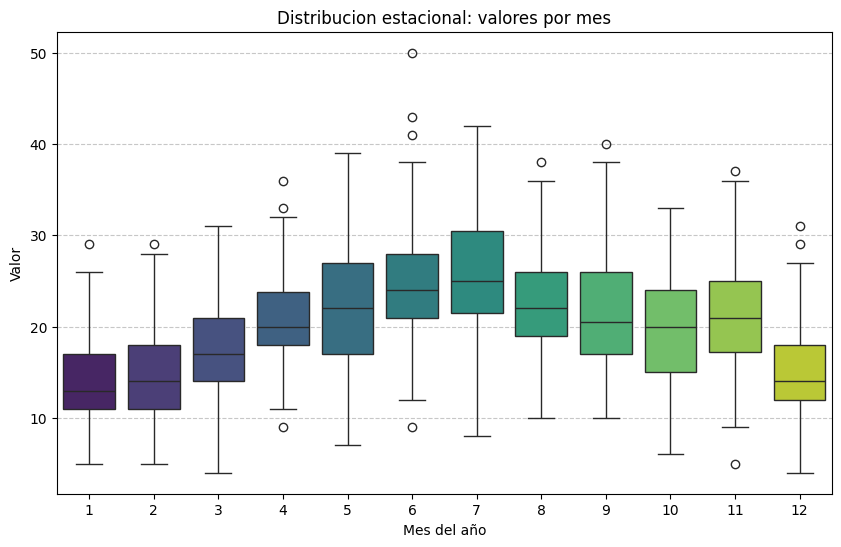

----------------------------------------
Correlacion con el año anterior: 0.4073
----------------------------------------
CONCLUSION: Existe una estacionalidad moderada
Hay un patron anual visible, pero con variaciones


In [ ]:
# Preparacion de datos
if 'df' not in locals():
    df = pd.read_csv('datosEjercicio.csv')

# Asegurarse de que es datetime
df['ds'] = pd.to_datetime(df['ds'])

# Creamos columna de mes para el grafico
df['month'] = df['ds'].dt.month

# GRAFICO: BOXPLOT MENSUAL

# Este grafico muestra la distribucion de valores agrupada por mes
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='month', y='y', palette='viridis')

plt.title('Distribucion estacional: valores por mes')
plt.xlabel('Mes del año')
plt.ylabel('Valor')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# COMPROBACION PROGRAMATICA (Autocorrelacion)
# Calculamos la correlacion entre el valor de hoy y el de hace exactamente un año (365 dias)
correlacion_anual = df['y'].corr(df['y'].shift(365))

print("-" * 40)
print(f"Correlacion con el año anterior: {correlacion_anual:.4f}")
print("-" * 40)

# Interpretacion del resultado
if correlacion_anual > 0.7:
    print("CONCLUSION: existe una fuerte estacionalidad anual")
    print("El patron se repite casi exactamente cada año")
elif correlacion_anual > 0.4:
    print("CONCLUSION: Existe una estacionalidad moderada")
    print("Hay un patron anual visible, pero con variaciones")
else:
    print("CONCLUSION: No parece haber un patron anual claro")
    print("Lo que pasó hace un año no predice bien lo que pasa hoy")

La hipótesis 1 parece confirmarse: existe estacionalidad, aunque moderada.

Observar que Noviembre parece ser un mes que rompe el ciclo de estacionalidad anual, presentando valores medios por encima de Octubre y Diciembre.

## **Hipótesis 2: Días Festivos**

Agreguemos al gráfico lineas verticales para identificar los festivos en España, buscando relación

In [ ]:
import plotly.express as px
import holidays

# Generamos festivos
anios_en_datos = df['ds'].dt.year.unique()
es_holidays = holidays.Spain(years=anios_en_datos)

# Gráfico base
fig = px.line(df, x='ds', y='y', title='Serie de Tiempo con Festivos de España')

# Agregamos líneas verticales para los festivos en España
min_date = df['ds'].min()
max_date = df['ds'].max()

for fecha, nombre_festivo in es_holidays.items():
    fecha_dt = pd.to_datetime(fecha)

    if min_date <= fecha_dt <= max_date:
        fig.add_vline(
            # .value da nanosegundos, dividimos por 10^6 para tener milisegundos
            x=fecha_dt.value // 10**6,

            line_width=1,
            line_dash="dash",
            line_color="red",
            opacity=0.5,
            annotation_text=nombre_festivo,
            annotation_position="top right",
            annotation_textangle=-90
        )

fig.show()

La Hipótesis 2 no pasa la comprobación visual: no parece haber una relación clara entre días festivos y valores altos o bajos de y

## **Hipótesis 3: Estacionalidad Intrasemanal**

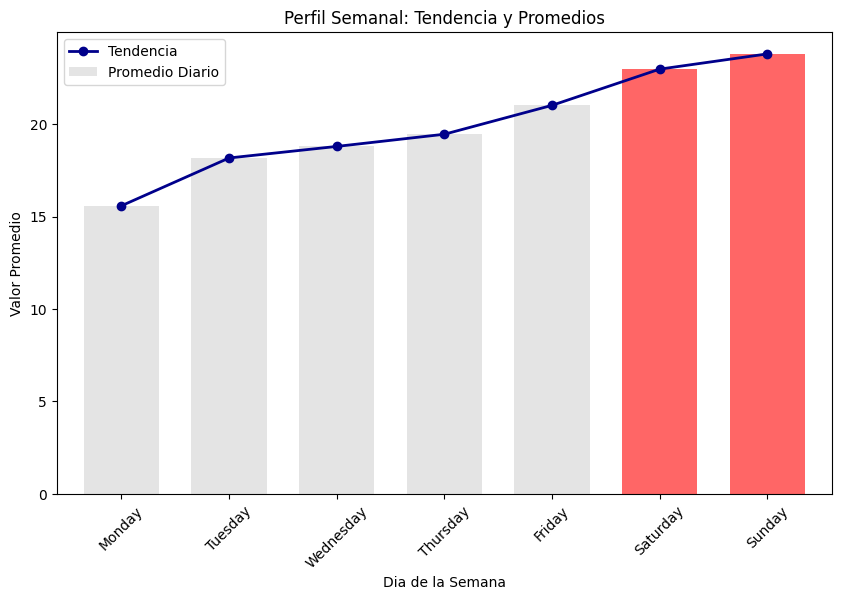

In [ ]:
# Cargamos los datos
if 'df' not in locals():
    df = pd.read_csv('datosEjercicio.csv')

df['ds'] = pd.to_datetime(df['ds'])
df['day_name'] = df['ds'].dt.day_name()

# Calculamos los promedios ordenados
promedios_por_dia = df.groupby('day_name')['y'].mean()
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
promedios_por_dia = promedios_por_dia.reindex(orden_dias)

# Configuracion del grafico
# Usamos subplots para tener mayor control sobre objetos superpuestos
fig, ax = plt.subplots(figsize=(10, 6))

# Definimos las barras
colores = ['red' if x in ['Saturday', 'Sunday'] else 'lightgray' for x in promedios_por_dia.index]
promedios_por_dia.plot(kind='bar', color=colores, ax=ax, width=0.7, alpha=0.6, label='Promedio Diario')

# Linea de tendencia
# Usamos range(len(...)) para las coordenadas X porque las barras son categoricas
x_coords = range(len(promedios_por_dia))
ax.plot(x_coords, promedios_por_dia.values, color='darkblue', marker='o', linestyle='-', linewidth=2, label='Tendencia')

# Detalles esteticos
ax.set_title('Perfil Semanal: Tendencia y Promedios')
ax.set_ylabel('Valor Promedio')
ax.set_xlabel('Dia de la Semana')
ax.set_xticklabels(promedios_por_dia.index, rotation=45)

# Agregamos leyenda para distinguir barra vs linea
ax.legend()

plt.show()

La Hipótesis 3 parece ser cierta: los valores de y son más altos los fines de semana.

Además la relación es casi ascendente para cada día: En promedio, el lunes es el día con valores menores de y, y va creciendo día a día hasta el domingo, donde encuentra un máximo.

## **Hipotesis 4 - DataSet relacionado al turismo**

Escogemos aplicar el modelo de prediccion Prophet (mostrado despues de los modelos de Alisado simple y triple) para este dataset por los siguientes motivos:

- **Multi-estacionalidad**: Prophet modela automáticamente tanto la estacionalidad semanal (el efecto del fin de semana) como la anual (el efecto del verano) sin necesidad de configuraciones complejas.

- **Resiliencia a Outliers**: Prophet utiliza una regresión robusta que evita que los outliers desvíen toda la predicción, algo que suele afectar negativamente a los otros modelos de alisado exponencial.

- **Datos Diarios**: está diseñado específicamente para datos con frecuencia diaria como los de este dataset.

# **Modelos**


## **Alisado Simple**

In [ ]:
x=df['y']
alpha=0.2 # damos un peso de 20% a los datos mas recientes y 80% a los datos mas antiguos
inicial= x[0]

# Hacemos un alisado exponencial manualmente
xPronostico=[inicial,inicial]

for i in range(1,len(x)):
    valor=alpha*x[i]+(1.0-alpha)*xPronostico[-1] # aplicamos la fórmula :: alpha * nueva + (1-alpha) * vieja
    xPronostico.append(valor) # guardamos el valor

# Imprimimos el pronostico
print("estimador de nivel: ",xPronostico[-1])

estimador de nivel:  18.843551245642303


El resultado del alisado simple nos da un pronostico de 18.8 a partir del 1 de enero del 2018 en adelante, es decir siempre será lo mismo.

Como el dataset tiene una clara tendencia semanal y anual, este modelo no nos sirve para hacer un buen forecasting de demanda ya que no considera la tendencia y la estacionalidad.


## **Alisado simple automático**

In [ ]:
from statsmodels.tsa.api import SimpleExpSmoothing

# Modelo simple con alpha definida por nosotros (0,2)
modelo1 = SimpleExpSmoothing(df['y']).fit(smoothing_level=0.2, optimized=False)

# Mostramos la información
print(modelo1.summary())
print("valores estimados:",modelo1.forecast(3))

                       SimpleExpSmoothing Model Results                       
Dep. Variable:                      y   No. Observations:                 1826
Model:             SimpleExpSmoothing   SSE                          55644.489
Optimized:                      False   AIC                           6243.178
Trend:                           None   BIC                           6254.197
Seasonal:                        None   AICC                          6243.200
Seasonal Periods:                None   Date:                 Tue, 24 Feb 2026
Box-Cox:                        False   Time:                         16:55:25
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.2000000                alpha                False
initial_level              13.000000                

In [ ]:
# Dejamos que el parámetro lo decida el código
modelo2 = SimpleExpSmoothing(df['y'],initialization_method="estimated").fit()


# Vanos a imprimir las métricas de error y los parámetros
print(modelo2.summary())

# Mostramos el pronóstico para los próximos 3 periodos
print("valores futuros:\n", modelo2.forecast(3))

# Vamos a mostrar cómo se ajustó el modelo a los datos históricos reales
print("valores anteriores:\n", modelo2.fittedvalues)

                       SimpleExpSmoothing Model Results                       
Dep. Variable:                      y   No. Observations:                 1826
Model:             SimpleExpSmoothing   SSE                          53363.054
Optimized:                       True   AIC                           6166.733
Trend:                           None   BIC                           6177.753
Seasonal:                        None   AICC                          6166.755
Seasonal Periods:                None   Date:                 Tue, 24 Feb 2026
Box-Cox:                        False   Time:                         16:55:26
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.0868429                alpha                 True
initial_level              11.077135                

In [ ]:
import pandas as pd
import plotly.graph_objs as go

# Definimos los periodos de forecast
forecast_periods = 365
forecast_modelo1 = modelo1.forecast(forecast_periods)
forecast_modelo2 = modelo2.forecast(forecast_periods)

# Fechas historicas (Extraemos directamente la columna 'ds')
fechas_historicas = df['ds']

# Generacion robusta de fechas futuras
# Tomamos la ultima fecha usando .iloc[-1] para evitar problemas de indices enteros
ultima_fecha = fechas_historicas.iloc[-1]
fechas_futuras = pd.date_range(
    start=ultima_fecha + pd.Timedelta(days=1),
    periods=forecast_periods,
    freq='D'
)

# Construccion del grafico
fig = go.Figure()

# Serie original
fig.add_trace(go.Scatter(x=fechas_historicas, y=df['y'], mode='lines', line=dict(color='black'), name='Serie original'))

# Valores ajustados (fit)
fig.add_trace(go.Scatter(x=fechas_historicas, y=modelo1.fittedvalues, mode='lines', line=dict(color='red', dash='dot'), name='Fit Modelo 1'))
fig.add_trace(go.Scatter(x=fechas_historicas, y=modelo2.fittedvalues, mode='lines', line=dict(color='blue', dash='dot'), name='Fit Modelo 2'))

# Forecast
fig.add_trace(go.Scatter(x=fechas_futuras, y=forecast_modelo1, mode='lines', line=dict(color='orange', width=2), name='Forecast Modelo 1'))
fig.add_trace(go.Scatter(x=fechas_futuras, y=forecast_modelo2, mode='lines', line=dict(color='green', width=2), name='Forecast Modelo 2'))

# Anadimos formato profesional
fig.update_layout(
    title='Proyección a 1 año vista (modelos de alisado)',
    xaxis_title='Fecha',
    yaxis_title='Variable Y',
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

La gráfica anterior confirma lo que concluimos con el modelo de alisado, ya que muestra gráficamente una línea futura recta, donde la demanda no varía. Por lo cual no refleja la estacionalidad de los datos que estamos analizando y se confirma que este modelo no es un método adecuado para hacer un forecasting de esta demanda.

## **Proceso manual**

In [ ]:
from scipy.optimize import minimize

# Copiamos los datos para evitar errores
x=df['y']

# Definimos la función de error
def mse(params, serie):

    inicial, alpha = params
    xPronostico=[inicial] # iniciamos con valor "inicial"
    for i in range(len(serie)):
        valor=alpha*serie[i]+(1.0-alpha)*xPronostico[-1] # aplicamos la fórmula
        xPronostico.append(valor) # guardamos el valor
    error = 0
    for i in range(len(serie)):
        error += (serie[i]-xPronostico[i])**2
    return error

# valores iniciales
initial_params = [x[0],0.0868]

# Optimizamos
result = minimize(mse, initial_params, args=(x,), method='L-BFGS-B')

# Imprimimos
if result.success:
    print(f"Parámetros optimización: {result.x}")
else:
    print("Error:", result.message)

Parámetros optimización: [11.0769325  0.0868437]


## **Alisado Triple**

In [ ]:
# Importamos las librerías
from statsmodels.tsa.api import ExponentialSmoothing
import plotly.graph_objs as go

# Dibujamos la serie
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['ds'],
                         y=df['y'],
                         mode='lines+markers',
                         name='Demanda'))
fig.update_layout(title='Demanda semanal',
                  xaxis_title='Periodos',
                  yaxis_title='Demanda')
fig.show()

In [ ]:
df_model = df.copy()
df_model['ds'] = pd.to_datetime(df_model['ds'])
df_model.set_index('ds', inplace=True)

# Asignamos la frecuencia temporal diaria
df_model.index.freq = 'D'

HoltWinters1 = ExponentialSmoothing(
    df_model['y'],
    seasonal_periods=7,
    trend="add",
    seasonal="add",
    initialization_method="estimated"
).fit()

print(HoltWinters1.summary())

forecast_modelo1 = HoltWinters1.forecast(8)
print(forecast_modelo1)

                       ExponentialSmoothing Model Results                       
Dep. Variable:                        y   No. Observations:                 1826
Model:             ExponentialSmoothing   SSE                          39385.059
Optimized:                         True   AIC                           5630.118
Trend:                         Additive   BIC                           5690.727
Seasonal:                      Additive   AICC                          5630.319
Seasonal Periods:                     7   Date:                 Tue, 24 Feb 2026
Box-Cox:                          False   Time:                         16:55:27
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.1072583                alpha                 True
smoothing_trend          

In [ ]:
HoltWinters2 = ExponentialSmoothing(

    df['y'],
    seasonal_periods=7, # usamos 7 porque tenemos una estacionalidad semanal fuerte comprobada en la hiptesis 3
    trend="add", # podriamos poner una satruacion en el mercado usando dampling
    seasonal="mul",
    #use_boxcox=True, #transformación logarítmica
    initialization_method="estimated",
).fit()
print(HoltWinters2.summary())

forecast_modelo2 = HoltWinters2.forecast(8)
print(forecast_modelo2)

                       ExponentialSmoothing Model Results                       
Dep. Variable:                        y   No. Observations:                 1826
Model:             ExponentialSmoothing   SSE                          38446.291
Optimized:                         True   AIC                           5586.067
Trend:                         Additive   BIC                           5646.676
Seasonal:                Multiplicative   AICC                          5586.268
Seasonal Periods:                     7   Date:                 Tue, 24 Feb 2026
Box-Cox:                          False   Time:                         16:55:28
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.1059197                alpha                 True
smoothing_trend          

In [ ]:
import pandas as pd
import plotly.graph_objs as go

# Aseguramos que el forecast sea para 1 ano (365 dias)
forecast_periods = 365
forecast_modelo1 = HoltWinters1.forecast(forecast_periods)
forecast_modelo2 = HoltWinters2.forecast(forecast_periods)

# Extraemos las fechas historicas de la columna 'ds'
fechas_historicas = df['ds']

# Generamos el indice temporal para el futuro
ultima_fecha = fechas_historicas.iloc[-1]
fechas_futuras = pd.date_range(
    start=ultima_fecha + pd.Timedelta(days=1),
    periods=forecast_periods,
    freq='D'
)

# Creamos la figura
fig = go.Figure()

# Serie original
fig.add_trace(go.Scatter(x=fechas_historicas, y=df['y'], mode='lines', line=dict(color='black'), name='Serie original'))

# Valores ajustados (fit) en lineas punteadas
fig.add_trace(go.Scatter(x=fechas_historicas, y=HoltWinters1.fittedvalues, mode='lines', line=dict(color='red', dash='dot'), name='Fit Aditivo'))
fig.add_trace(go.Scatter(x=fechas_historicas, y=HoltWinters2.fittedvalues, mode='lines', line=dict(color='blue', dash='dot'), name='Fit Multiplicativo'))

# Forecast a 1 ano (lineas solidas mas gruesas)
fig.add_trace(go.Scatter(x=fechas_futuras, y=forecast_modelo1, mode='lines', line=dict(color='orange', width=2), name='Forecast Aditivo'))
fig.add_trace(go.Scatter(x=fechas_futuras, y=forecast_modelo2, mode='lines', line=dict(color='lightblue', width=2), name='Forecast Multiplicativo'))

# Formato profesional del layout
fig.update_layout(
    title='Proyección a 1 año: Holt-Winters aditivo vs multiplicativo',
    xaxis_title='Fecha',
    yaxis_title='Variable Y',
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

En el Alisado Triple consideramos 7 periodos para tener en cuenta la estacionalidad semanal. Usamos la estacionalidad semanal ya que esta es constante con picos en el fin de semana, diferente a la estacionalidad anual donde hay un pico en noviembre que no podemos explicar.

En la gráfica, también podemos observar como la línea futura refleja la estacionalidad semanal de los datos, en los dos modelos.

Aunque los dos modelos reflejan la estacionalidad de los datos, el modelo 2 nos da un AICC un poco mas bajo, que indica un mejor ajuste a los datos.

Debido a que con el alisado triple no pueden manejar la estacionalidad semanal y anual haremos el modelo prophet a continuación.

## **Modelo Prophet**

In [ ]:
from prophet import Prophet

# Inicializamos el modelo
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False # Son datos diarios, no por horas
)

# Entrenamos el modelo
model.fit(df)

In [ ]:
# Creamos un dataframe con las fechas futuras
future = model.make_future_dataframe(periods=365)

# Ejecutamos la predicción
forecast = model.predict(future)

# Mostramos las últimas filas de la predicción
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

             ds       yhat  yhat_lower  yhat_upper
2186 2018-12-27  17.104848   11.248425   22.340746
2187 2018-12-28  18.778251   12.748764   24.294358
2188 2018-12-29  20.835930   15.275438   26.278074
2189 2018-12-30  21.747209   15.942278   27.312302
2190 2018-12-31  13.601677    8.009261   19.345197


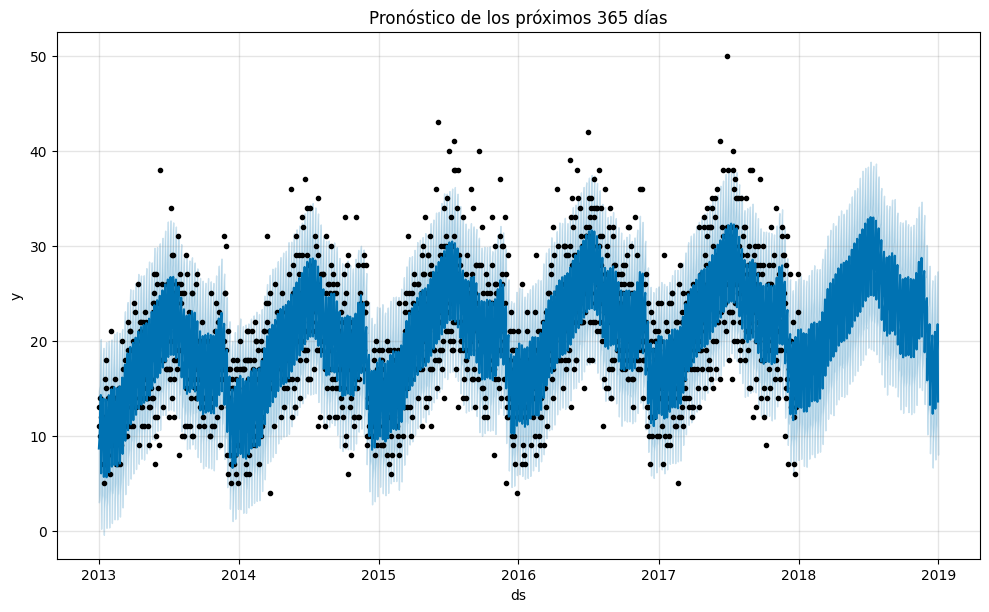

In [ ]:
# Gráfica 1
# Mostramos la union de dataset real con el forecast creado
fig1 = model.plot(forecast)
plt.title('Pronóstico de los próximos 365 días')
plt.show()

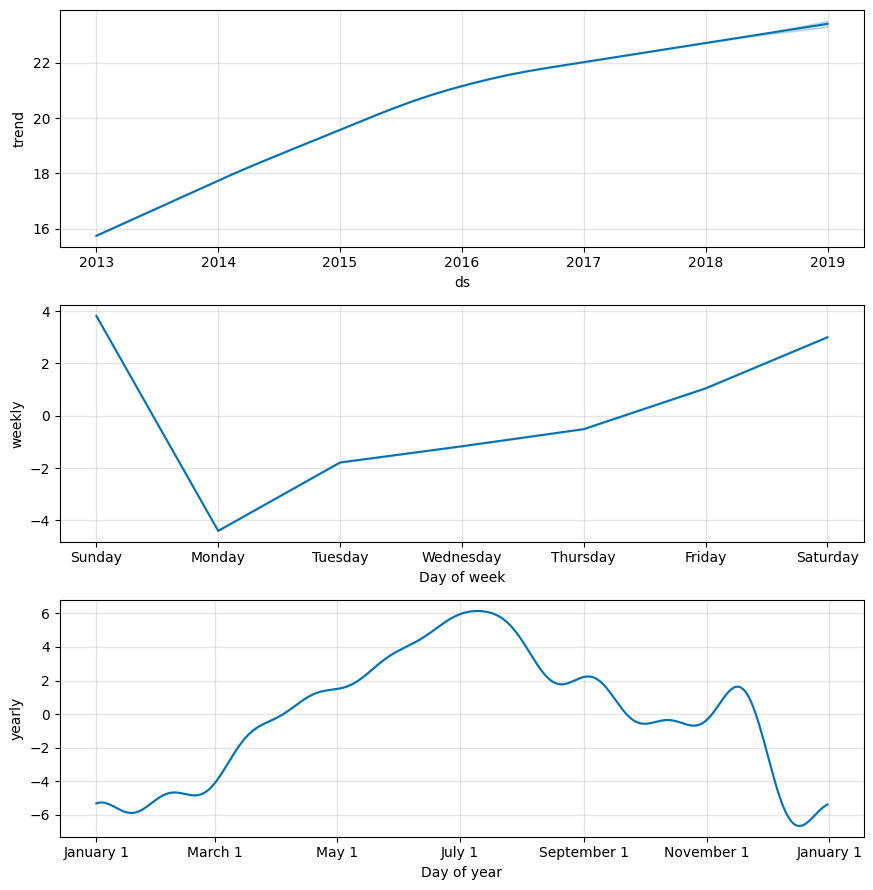

In [ ]:
# Gráfica 2
# Separamps la tendencia, la estacionalidad semanal y la anual
fig2 = model.plot_components(forecast)
plt.show()

Tendencia (Trend): El modelo confirma un crecimiento sostenido a largo plazo.

Weekly (Semanal): Los dias fin de semana tienen el mayor impacto positivo en y.

Yearly (Anual): Se observa claramente el valle en invierno y el pico en junio-julio.

Contexto (Hipotesis 4): Los patrones coinciden con un sector de alta actividad en fin de semana y vacaciones, como el turismo.


## **Validación Cruzada**
Vamos a demostrar que el modelo es estable en diferentes periodos de tiempo

In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

# Evaluamos el modelo:
# initial: cuánto tiempo necesita para empezar a aprender
# period: cada cuánto tiempo hace una prueba
# horizon: a cuánto tiempo intenta predecir en cada prueba
df_cv = cross_validation(model, initial='730 days', period='180 days', horizon='365 days')

# Calculamos las métricas (MSE, RMSE, MAE, MAPE)
df_p = performance_metrics(df_cv)
print(df_p.head())

INFO:prophet:Making 5 forecasts with cutoffs between 2015-01-11 00:00:00 and 2016-12-31 00:00:00


  horizon        mse      rmse       mae      mape     mdape     smape  \
0 37 days  21.473818  4.633985  3.766583  0.243573  0.152148  0.207347   
1 38 days  21.548818  4.642070  3.758857  0.245361  0.152148  0.207912   
2 39 days  21.587312  4.646215  3.764763  0.245445  0.146396  0.208067   
3 40 days  21.531768  4.640234  3.751815  0.247930  0.146396  0.209327   
4 41 days  21.691623  4.657427  3.759879  0.246013  0.146396  0.208397   

   coverage  
0  0.763736  
1  0.764835  
2  0.767033  
3  0.767033  
4  0.763736  


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



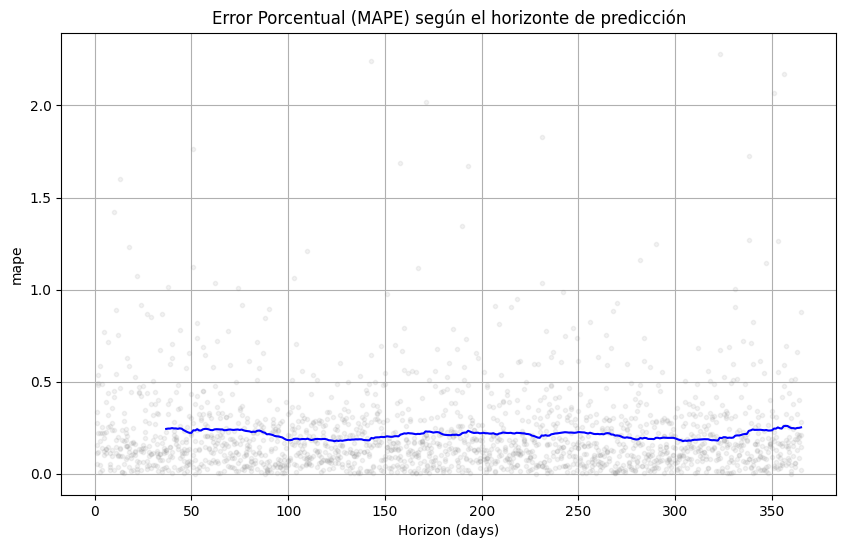

In [ ]:
# Vamos a ver como se comporta el error a medida que intentamos predecir más lejos en el futuro
fig_cv = plot_cross_validation_metric(df_cv, metric='mape')
plt.title("Error Porcentual (MAPE) según el horizonte de predicción")
plt.show()

El modelo presenta un MAPE que ronda el 0.25, lo que indica que, en promedio, nuestras predicciones se desvían solo un 25% del valor real, lo cual es aceptable para una serie temporal con esta volatilidad. Ademas es un valor constante.

## **Otras validaciones**

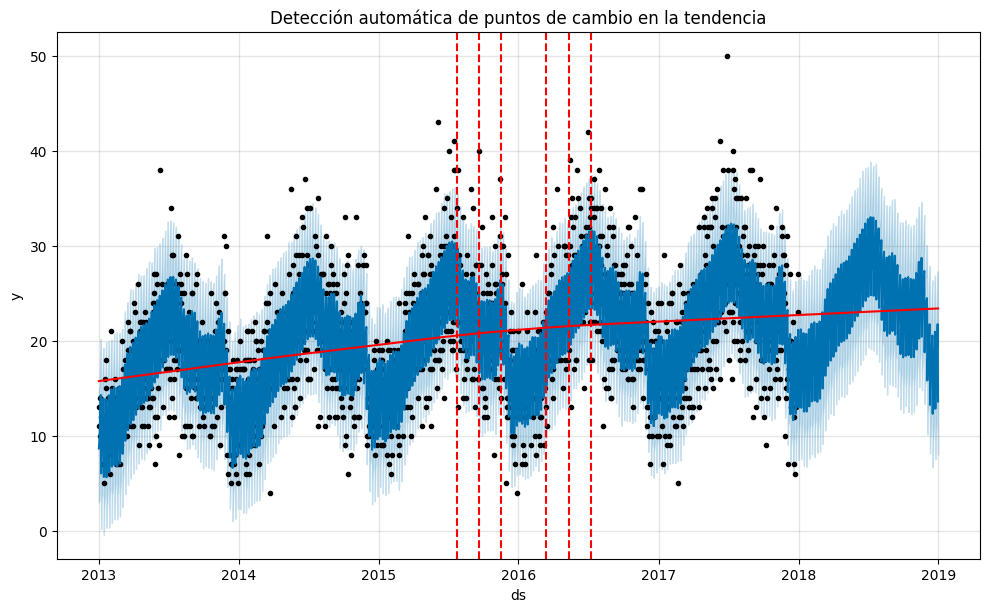

In [ ]:
from prophet.plot import add_changepoints_to_plot

fig = model.plot(forecast)
# Añadimos líneas rojas donde el modelo detectó cambios bruscos en la tendencia
a = add_changepoints_to_plot(fig.gca(), model, forecast)
plt.title("Detección automática de puntos de cambio en la tendencia")
plt.show()

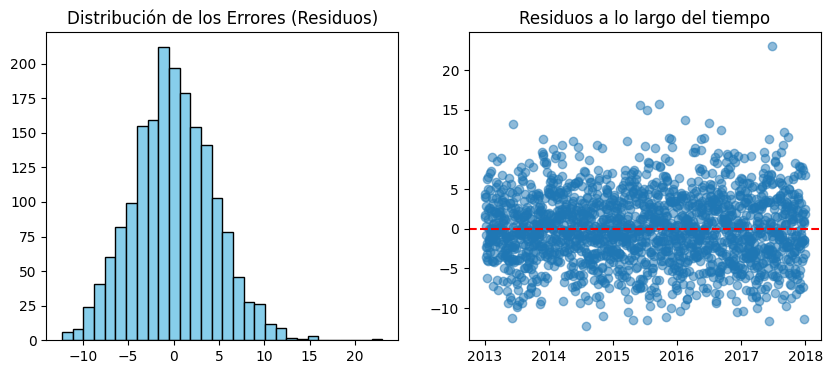

In [ ]:
# Calculamos los residuos (real - valor predicho)
residuos = df['y'] - forecast.iloc[:len(df)]['yhat']

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(residuos, bins=30, edgecolor='black', color='skyblue')
plt.title("Distribución de los Errores (Residuos)")

plt.subplot(1,2,2)
plt.scatter(df['ds'], residuos, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuos a lo largo del tiempo")
plt.show()

## **Conclusiones**

Tras el análisis realizado, el modelo Prophet ha demostrado ser altamente eficaz para este dataset por su capacidad de absorber la tendencia creciente y las fluctuaciones estacionales (especialmente el pico de los domingos y la temporada de verano). Las métricas de error obtenidas mediante validación cruzada confirman que el modelo tiene una gran capacidad predictiva con un margen de error mínimo, siendo una herramienta fiable para la toma de decisiones estratégicas a un año vista.